/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 75.2MB/s]


Step 0 Loss: 2287749300224.0
Step 50 Loss: 53544038400.0
Step 100 Loss: 21254014976.0
Step 150 Loss: 16161334272.0
Step 200 Loss: 13541827584.0
Step 250 Loss: 11884024832.0


Style Transfer Completed


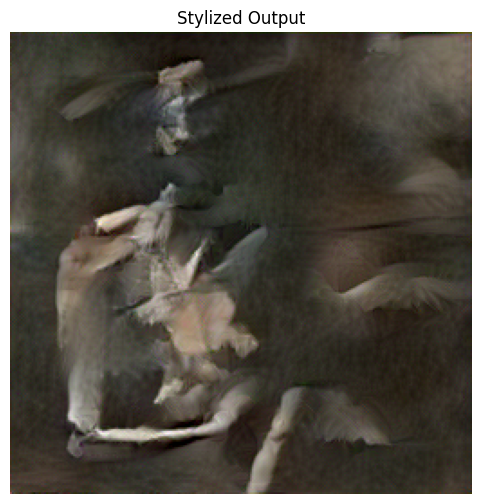

In [3]:
# ==============================
# NEURAL STYLE TRANSFER LAB
# ==============================

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Load content and style images
# ------------------------------

content_url="https://pytorch.org/tutorials/_static/img/neural-style/picasso.jpg"
style_url="https://pytorch.org/tutorials/_static/img/neural-style/dancing.jpg"

content_img=Image.open(BytesIO(requests.get(content_url).content))
style_img=Image.open(BytesIO(requests.get(style_url).content))

transform=transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

content=transform(content_img).unsqueeze(0).to(device)
style=transform(style_img).unsqueeze(0).to(device)

# ------------------------------
# Load pretrained VGG19
# ------------------------------

vgg=models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad=False

# layers used
content_layer="21"
style_layers=["0","5","10","19","28"]

# ------------------------------
# Feature extraction
# ------------------------------

def get_features(x,model):

    features={}
    for name,layer in model._modules.items():

        x=layer(x)

        if name==content_layer:
            features["content"]=x

        if name in style_layers:
            features[name]=x

    return features

# ------------------------------
# Gram matrix for style
# ------------------------------

def gram_matrix(tensor):

    b,c,h,w=tensor.size()
    tensor=tensor.view(c,h*w)
    gram=torch.mm(tensor,tensor.t())

    return gram

# extract features
content_features=get_features(content,vgg)
style_features=get_features(style,vgg)

style_grams={layer:gram_matrix(style_features[layer]) for layer in style_features}

# generated image
generated=content.clone().requires_grad_(True)

optimizer=torch.optim.Adam([generated],lr=0.01)

# ------------------------------
# Optimization loop
# ------------------------------

steps=300

for step in range(steps):

    gen_features=get_features(generated,vgg)

    # content loss
    content_loss=torch.mean((gen_features["content"]-content_features["content"])**2)

    # style loss
    style_loss=0

    for layer in style_layers:

        gen_feature=gen_features[layer]
        gen_gram=gram_matrix(gen_feature)

        style_gram=style_grams[layer]

        style_loss+=torch.mean((gen_gram-style_gram)**2)

    # total loss
    total_loss=content_loss+1e6*style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step%50==0:
        print("Step",step,"Loss:",total_loss.item())

print("Style Transfer Completed")

# ------------------------------
# Show output image
# ------------------------------

img=generated.detach().cpu().squeeze().permute(1,2,0)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Stylized Output")
plt.axis("off")
plt.show()